In [ ]:
from transformers import pipeline
from PIL import Image
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import warnings
import torch
import cv2
import numpy as np
warnings.filterwarnings("ignore")
path = "/content/drive/MyDrive/Heaxa proj/road.jpg"

## Depth Anything Small

In [ ]:
# pipe = pipeline("depth-estimation", model="depth-anything/Depth-Anything-V2-Small-hf")


In [ ]:

# image = Image.open(path)
# depth = pipe(image)["depth"]

# plt.imshow(image, cmap="magma")
# plt.axis("off")
# plt.show()
# plt.imshow(depth, cmap="magma")
# plt.axis("off")
# plt.tight_layout()
# plt.show()

## Depth Anything Large

In [ ]:
#pipe = pipeline("depth-estimation", model="depth-anything/Depth-Anything-V2-Large-hf")

In [ ]:

# image = Image.open(path)
# depth = pipe(image)["depth"]
# plt.imshow(image, cmap="magma")
# plt.axis("off")
# plt.show()
# plt.imshow(depth, cmap="magma")
# plt.axis("off")
# plt.tight_layout()
# plt.show()

## Zeodepth

In [ ]:
#pipe = pipeline("depth-estimation", model="Intel/zoedepth-nyu-kitti")

In [ ]:

# image = Image.open(path)
# result = pipe(image)

# depth = result["predicted_depth"]
# print(f"Closest point: {depth.min():.2f}m")
# print(f"Farther point: {depth.max():.2f}m")
# plt.imshow(depth, cmap="magma")
# plt.axis("off")
# plt.tight_layout()
# plt.show()

## DPT

In [ ]:
#pipe = pipeline("depth-estimation", model="Intel/dpt-large")

In [ ]:
# image = Image.open(path)
# depth = pipe(image)["depth"]
# plt.imshow(depth, cmap="magma")
# plt.axis("off")
# plt.tight_layout()
# plt.show()


## Midas

In [ ]:
model = torch.hub.load("intel-isl/MiDaS", "MiDaS_small")
model.eval()
transforms = torch.hub.load("intel-isl/MiDaS", "transforms").small_transform


Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master
Using cache found in /root/.cache/torch/hub/rwightman_gen-efficientnet-pytorch_master


Loading weights:  None


Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


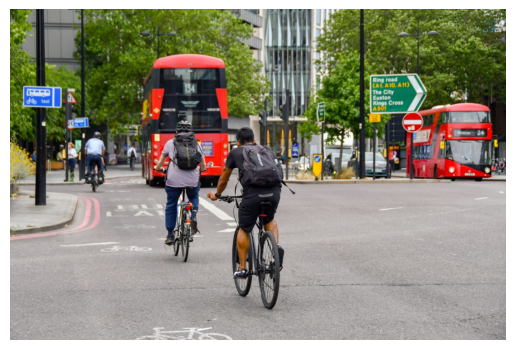

In [ ]:
img = cv2.imread(path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

input_tensor = transforms(img)
with torch.no_grad():
    depth_pre = model(input_tensor).squeeze().numpy()


plt.imshow(img, cmap="magma")
plt.axis("off")
plt.show()


## Helper Functions

In [ ]:
red   = [255, 0,   0]
green = [0,   255, 0]
blue  = [0,   0, 255]

def visualize(depth_map, indices, x, y, t):
    palette   = np.array([red, green, blue], dtype=np.uint8)
    color_map = palette[indices]

    total    = indices.size
    near_pct = (indices == 0).sum() / total * 100
    mid_pct  = (indices == 1).sum() / total * 100
    far_pct  = (indices == 2).sum() / total * 100

    if t and x is not None and y is not None:
        color_map[x, y] = [0, 0, 0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.tight_layout()
    fig.suptitle(f"Depth Map: {depth_map.shape[1]} × {depth_map.shape[0]} px", fontsize=14)

    axes[0].imshow(depth_map, cmap='magma_r')
    axes[0].set_title("Heat Map")
    axes[0].axis('off')

    axes[1].imshow(color_map)
    axes[1].set_title("Regions")
    axes[1].axis('off')

    patches = [
        mpatches.Patch(color=np.array(red)  / 255, label=f"Near  {near_pct:.1f}%"),
        mpatches.Patch(color=np.array(green)/ 255, label=f"Mid   {mid_pct:.1f}%"),
        mpatches.Patch(color=np.array(blue) / 255, label=f"Far   {far_pct:.1f}%"),
    ]
    axes[1].legend(handles=patches, loc='upper right', fontsize=9, framealpha=0.5, edgecolor='#ccc')
    plt.show()


def depth_map_processing(depth_map: np.ndarray, x=None, y=None, t=0,visual=0):

    d_min, d_max = depth_map.min(), depth_map.max()
    depth_norm = 255 - ((depth_map - d_min) * 255 / (d_max - d_min)).astype("uint8")

    indices = np.where(depth_norm < 85,  0,np.where(depth_norm < 170, 1, 2))

    labels  = np.where(depth_norm < 85,  "near",np.where(depth_norm < 170, "mid", "far"))

    if visual==1:
      visualize(depth_norm, indices, x, y, t)

    return depth_norm, labels




## Pixel estimation

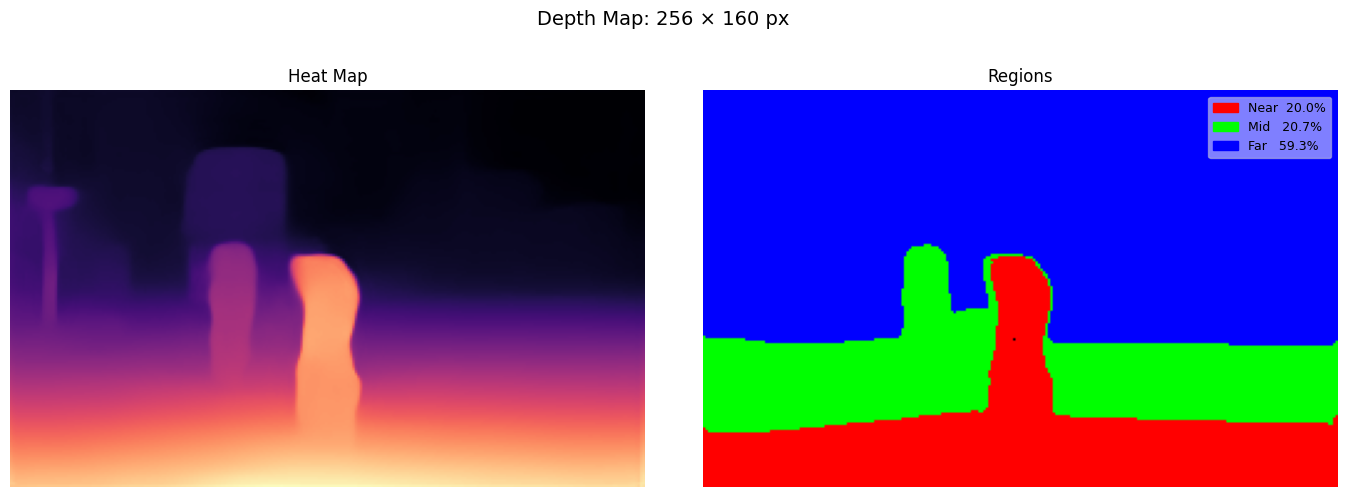

Etsimation: near


In [ ]:
depth, labels = depth_map_processing(depth_pre, x=100, y=125, t=1, visual=1)
print("Etsimation:", labels[100, 125])

### The estimated point colord with black


